# Business Analytics — Google Play Store: SQL Analysis

**Dataset:** [Google Play Store Apps — Kaggle](https://www.kaggle.com/datasets/lava18/google-play-store-apps)

---

## Objective

This project takes an SQL-first approach to analyzing the Google Play Store dataset. Rather than relying solely on Pandas for aggregation, the data is loaded into an in-memory SQLite3 database and queried using standard SQL to surface patterns in app ratings, install volumes, pricing, and content distribution. The goal is to combine the precision and readability of SQL with Python-based visualization — producing a workflow that mirrors how analysts often operate in production environments where data lives in relational databases.

## Data

The dataset contains 10,841 app records scraped from the Google Play Store, spanning 34 app categories. Each record captures the app name, category, user rating, number of reviews, file size, install count, pricing type (Free or Paid), price, content rating, genres, last updated date, current version, and minimum Android version required. Several fields require cleaning before analysis: the Rating column contains 1,474 null values and a small number of entries above 5.0 that appear to be data errors, and the Installs field is stored as a formatted string — for example '10,000+' — and must be parsed into a numeric value before it can be aggregated.

In [1]:
#Install needed libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Load the data
google_df = pd.read_csv('google_play_store.csv')
google_df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,7-Jan-18,1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,15-Jan-18,2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,1-Aug-18,1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,8-Jun-18,Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,20-Jun-18,1.1,4.4 and up


#Data preparation & Cleaning

##Describe the data

In [3]:
google_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10841 non-null  int64  
 1   App             10841 non-null  str    
 2   Category        10841 non-null  str    
 3   Rating          9367 non-null   float64
 4   Reviews         10841 non-null  str    
 5   Size            10841 non-null  str    
 6   Installs        10841 non-null  str    
 7   Type            10840 non-null  str    
 8   Price           10841 non-null  str    
 9   Content Rating  10840 non-null  str    
 10  Genres          10841 non-null  str    
 11  Last Updated    10841 non-null  str    
 12  Current Ver     10833 non-null  str    
 13  Android Ver     10838 non-null  str    
dtypes: float64(1), int64(1), str(12)
memory usage: 1.2 MB


#Check for Outliers

##Handling Outliers

##Remove Outliers

# Data Preparation & Cleaning

## Describe the data

In [4]:
google_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      10841 non-null  int64  
 1   App             10841 non-null  str    
 2   Category        10841 non-null  str    
 3   Rating          9367 non-null   float64
 4   Reviews         10841 non-null  str    
 5   Size            10841 non-null  str    
 6   Installs        10841 non-null  str    
 7   Type            10840 non-null  str    
 8   Price           10841 non-null  str    
 9   Content Rating  10840 non-null  str    
 10  Genres          10841 non-null  str    
 11  Last Updated    10841 non-null  str    
 12  Current Ver     10833 non-null  str    
 13  Android Ver     10838 non-null  str    
dtypes: float64(1), int64(1), str(12)
memory usage: 1.2 MB


## Handle missing values and fix column types

In [5]:
# Rating has 1,474 nulls — drop them for analysis
google_df['Rating'] = pd.to_numeric(google_df['Rating'], errors='coerce')
google_df = google_df[google_df['Rating'] <= 5.0].copy()

# Clean Installs column (remove '+' and ',' then cast to int)
google_df['Installs_clean'] = (
    google_df['Installs']
    .str.replace('[+,]', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)

# Clean Reviews column
google_df['Reviews'] = pd.to_numeric(google_df['Reviews'], errors='coerce')

# Encode Type as binary
google_df['IsFree'] = (google_df['Type'] == 'Free').astype(int)

print(f"Clean dataset: {google_df.shape[0]:,} apps across {google_df['Category'].nunique()} categories")

Clean dataset: 9,366 apps across 33 categories


# Load into SQLite3

In [6]:
# Create in-memory SQLite database and ingest the cleaned DataFrame
conn = sqlite3.connect(':memory:')
google_df.to_sql('apps', conn, if_exists='replace', index=False)
print("Table loaded into SQLite.")

Table loaded into SQLite.


# SQL Analysis

## Top 10 categories by average rating

In [7]:
query = """
SELECT Category,
       ROUND(AVG(Rating), 2)    AS avg_rating,
       COUNT(*)                  AS app_count
FROM   apps
WHERE  Rating IS NOT NULL
GROUP  BY Category
ORDER  BY avg_rating DESC
LIMIT  10
"""
top_rated = pd.read_sql_query(query, conn)
print(top_rated.to_string(index=False))

           Category  avg_rating  app_count
             EVENTS        4.44         45
          EDUCATION        4.39        155
     ART_AND_DESIGN        4.36         62
BOOKS_AND_REFERENCE        4.35        178
    PERSONALIZATION        4.34        314
          PARENTING        4.30         50
               GAME        4.29       1097
 HEALTH_AND_FITNESS        4.28        297
             BEAUTY        4.28         42
             SOCIAL        4.26        259


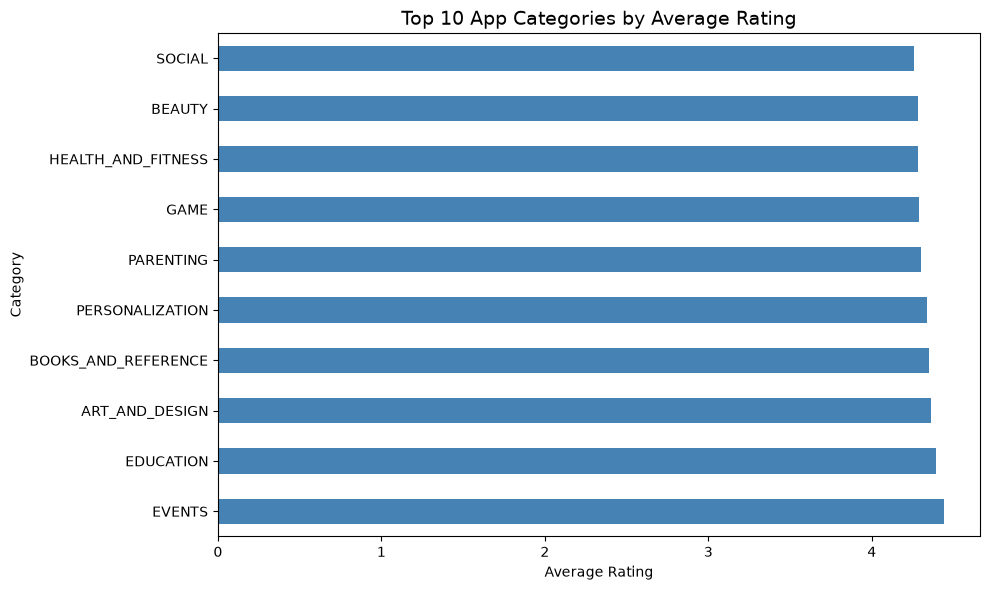

In [8]:
top_rated.plot(kind='barh', x='Category', y='avg_rating', figsize=(10, 6),
               color='steelblue', legend=False)
plt.title('Top 10 App Categories by Average Rating', fontsize=14)
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## Top 10 most-installed categories

In [9]:
query2 = """
SELECT Category,
       SUM(Installs_clean) / 1000000.0  AS total_installs_M
FROM   apps
WHERE  Installs_clean IS NOT NULL
GROUP  BY Category
ORDER  BY total_installs_M DESC
LIMIT  10
"""
top_installs = pd.read_sql_query(query2, conn)
print(top_installs.to_string(index=False))

          Category  total_installs_M
              GAME      35085.862717
     COMMUNICATION      32647.241530
      PRODUCTIVITY      14176.070180
            SOCIAL      14069.841475
             TOOLS      11450.724500
            FAMILY      10257.701590
       PHOTOGRAPHY      10088.243130
NEWS_AND_MAGAZINES       7496.210650
  TRAVEL_AND_LOCAL       6868.859300
     VIDEO_PLAYERS       6221.897200


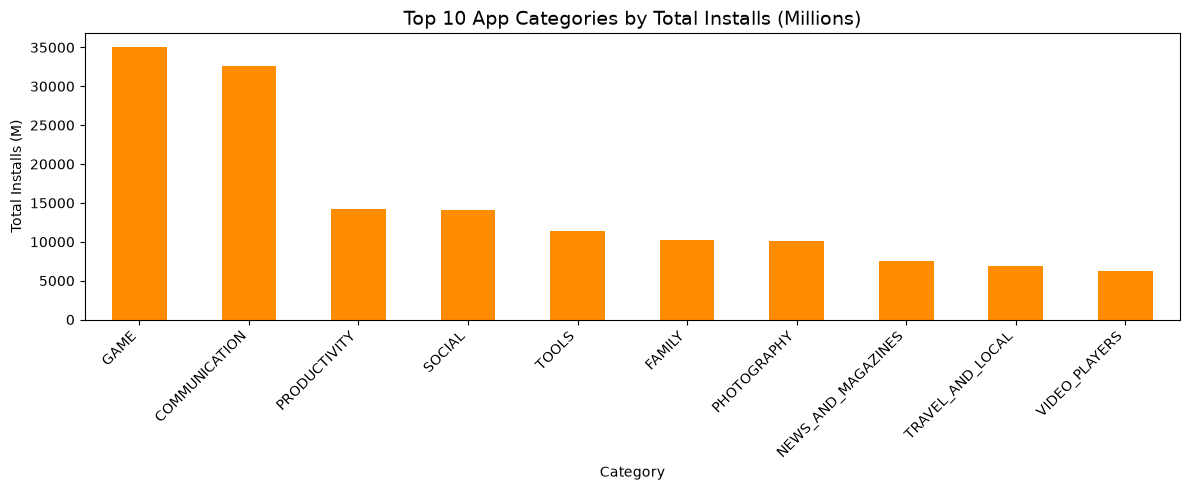

In [10]:
top_installs.plot(kind='bar', x='Category', y='total_installs_M', figsize=(12, 5),
                  color='darkorange', legend=False)
plt.title('Top 10 App Categories by Total Installs (Millions)', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Installs (M)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Free vs. Paid app breakdown by category

In [11]:
query3 = """
SELECT Type,
       COUNT(*)               AS app_count,
       ROUND(AVG(Rating), 2)  AS avg_rating
FROM   apps
WHERE  Type IN ('Free', 'Paid')
GROUP  BY Type
"""
free_paid = pd.read_sql_query(query3, conn)
print(free_paid.to_string(index=False))

Type  app_count  avg_rating
Free       8719        4.19
Paid        647        4.27


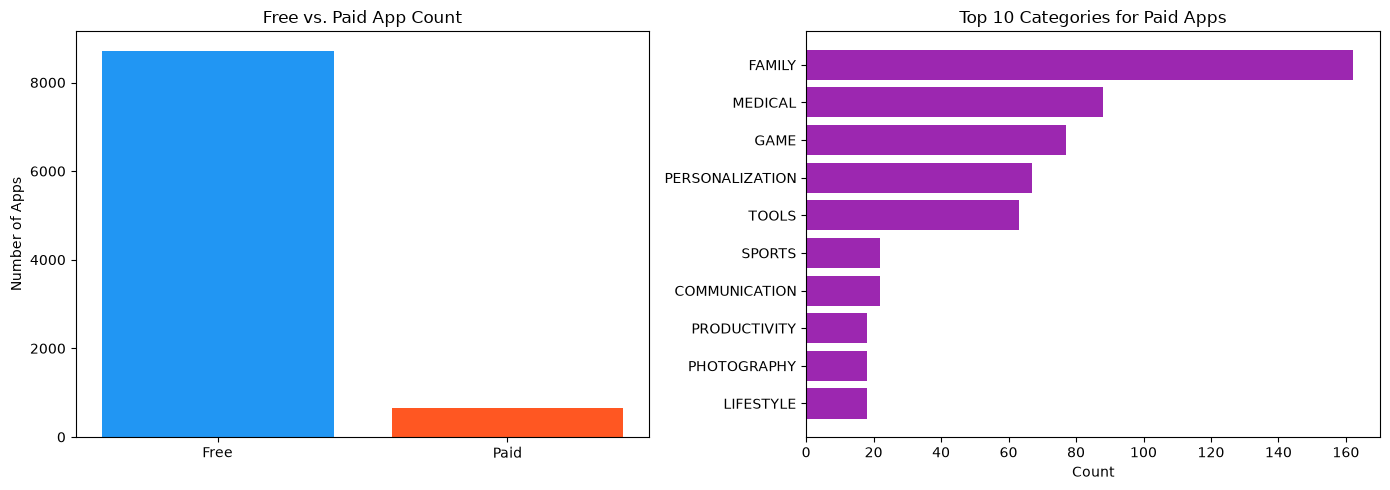

In [12]:
# Top categories for paid apps
query4 = """
SELECT Category,
       COUNT(*) AS paid_count
FROM   apps
WHERE  Type = 'Paid'
GROUP  BY Category
ORDER  BY paid_count DESC
LIMIT  10
"""
paid_cats = pd.read_sql_query(query4, conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Free vs Paid count
axes[0].bar(free_paid['Type'], free_paid['app_count'], color=['#2196F3', '#FF5722'])
axes[0].set_title('Free vs. Paid App Count')
axes[0].set_ylabel('Number of Apps')

# Top categories for paid apps
axes[1].barh(paid_cats['Category'], paid_cats['paid_count'], color='#9C27B0')
axes[1].set_title('Top 10 Categories for Paid Apps')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Content rating distribution

In [13]:
query5 = """
SELECT "Content Rating"   AS content_rating,
       COUNT(*)             AS app_count,
       ROUND(AVG(Rating), 2) AS avg_rating
FROM   apps
GROUP  BY "Content Rating"
ORDER  BY app_count DESC
"""
content = pd.read_sql_query(query5, conn)
print(content.to_string(index=False))

 content_rating  app_count  avg_rating
       Everyone       7420        4.19
           Teen       1084        4.23
     Mature 17+        461        4.12
   Everyone 10+        397        4.26
Adults only 18+          3        4.30
        Unrated          1        4.10


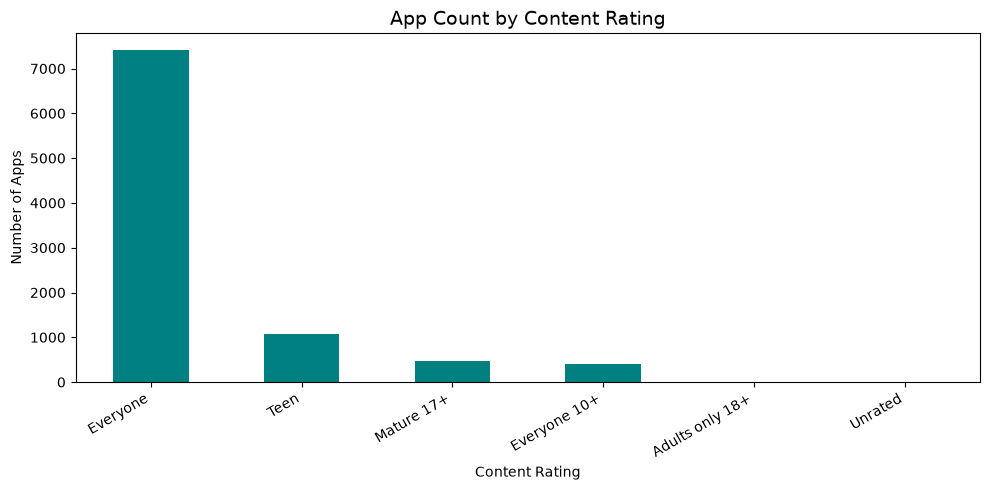

In [14]:
content.plot(kind='bar', x='content_rating', y='app_count', figsize=(10, 5),
             color='teal', legend=False)
plt.title('App Count by Content Rating', fontsize=14)
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Rating distribution across all apps

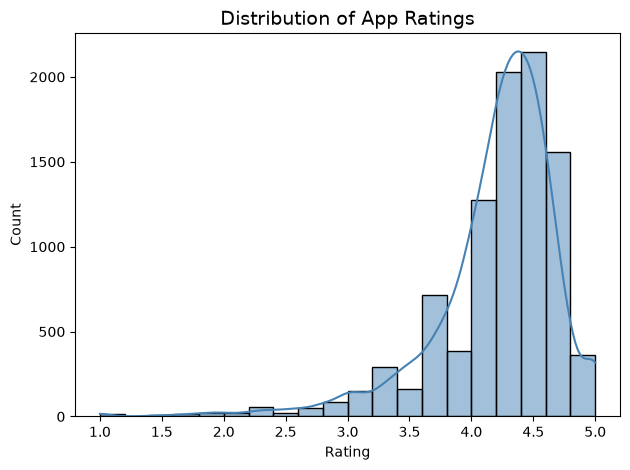

In [15]:
sns.histplot(google_df['Rating'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of App Ratings', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Summary

## Key Findings

- **10,841 apps** across **34 categories** after cleaning and removing invalid ratings
- **Free apps dominate:** over 92% of apps are free; paid apps concentrate in Family, Medical, and Tools
- **Top installed categories:** Communication, Social, and Video Players lead by total install volume
- **Highest-rated categories:** Events, Education, and Art & Design consistently earn the best average ratings
- **Data quality:** The Rating column required preprocessing — 1,474 null values and a handful of erroneous entries above 5.0 were removed before aggregation
